# Backpropagation, from first principles

A hand-written walkthrough of backpropagation, in two parts:

- **Part 1 — Building the engine.** A minimal `Value` class that records how numbers combine (add, multiply, `sigmoid`, `tanh`, ...) so the resulting computation graph can be visualized.
- **Part 2 — Manual backpropagation.** Starting from an output, we manually compute and assign the gradient of every upstream value by hand, applying the chain rule one operation at a time — making explicit what an autograd engine (e.g. PyTorch) normally does for you.

- **Part 3- Automatic backpropogation.** Creating functions inside "Value" that automatically calculate gradients, a mini PyTorch-esque engine.

- **Part 4- Weight updating using SGD.** Why SGD isnt enough, exploring Adam and other popular gradient descent and ascent methods. Hyper-parameter tuning options and their effects

## Part 1 — Building a tiny autograd-style engine

Before anything can be backpropagated, we need numbers that remember how they were computed. That's what the `Value` class below does.

In [2]:
import os

# This forces Python to look exactly where the file lives
graphviz_path = r"C:\Program Files (x86)\Graphviz\bin"

if graphviz_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + graphviz_path


In [3]:
import math
from graphviz import Digraph

`DES_PRECISION` sets how many decimal places `Value`'s arithmetic operations round results to, this is purely to keep printed numbers tidy.

In [4]:
DES_PRECISION=15

### The `Value` class

Each `Value` wraps a scalar together with the bookkeeping backprop needs:

- `data` — the actual numeric value
- `_prev` — the values it was built from (its "children" in the computation graph)
- `_op` — the operation that produced it (`+`, `*`, `tanh`, ...)
- `grad` — the gradient of the final output with respect to this value, initialized to `0.0` and filled in by hand throughout Part 2

Every operator (`+`, `-`, `*`, `/`, `**`) and activation (`relu`, `tanh`, `sigmoid`) returns a *new* `Value` linked back to its inputs, so the full history of a computation can be traced afterwards. Note that this only implements the **forward** pass. there is no automatic `.backward()` here, since the point of this notebook is to compute gradients by hand.

In [5]:

class Value():

    def __init__(self, data: float, label: str = '', _children=(), _op=''):
        self.data = data
        self.label = label
        self._prev = set(_children)
        self._op = _op
        self.grad = 0.0 # Initialize gradient

    def __add__(self, other):
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other_value.data, _children=(self, other_value), _op='+')
        return out

    def __sub__(self, other):
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(self.data - other_value.data, _children=(self, other_value), _op='-')
        return out

    def __rsub__(self, other):
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(other_value.data - self.data, _children=(other_value, self), _op='-')
        return out

    def __mul__(self, other):
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(round(self.data * other_value.data, DES_PRECISION), _children=(self, other_value), _op='*')
        return out

    def __rmul__(self, other):
        return self.__mul__(other)

    def __truediv__(self, other):
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(round(self.data / other_value.data, DES_PRECISION), _children=(self, other_value), _op='/')
        return out

    def __pow__(self, other):
        if isinstance(other, (int, float)):
            out = Value(round(self.data ** other, DES_PRECISION), _children=(self,), _op='^')
        else:
            out = Value(round(self.data ** other.data, DES_PRECISION), _children=(self, other), _op='^')
        return out

    def relu(self):
        out_data = 0 if self.data < 0 else self.data
        out = Value(out_data, _children=(self,), _op='ReLU')
        return out

    def tanh(self):
        out_data = math.tanh(self.data)
        out = Value(out_data, _children=(self,), _op='tanh')
        return out

    def sigmoid(self):
        out_data = 1 / (1 + math.exp(-self.data))
        out = Value(round(out_data, DES_PRECISION), _children=(self,), _op='σ')
        return out

    def __repr__(self):
        return f"Value(data={self.data:.4f}, label='{self.label}', grad={self.grad:.4f})"


### Visualizing the computation graph

`trace` walks the graph backward from a root `Value` to collect every node and edge. `draw_dot` then renders it left-to-right with Graphviz: rectangular nodes show a value's `data` and `grad`, and oval nodes show the operation that produced them.
Honestly, you dont need to concern yourself with this at all. The goal is to help understand the process of machine learning for neural networks THROUGH visualisation.

In [6]:
def trace(root):
    # Builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Draw the rectangle node for the value and gradient
        # label shows: [variable_name] | data | grad
        label = f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}"
        dot.node(name=uid, label=label, shape='record')

        if n._op:
            # If this node was created by an operation, draw an operation node
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # Connect nodes to their operation node
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

### Forward pass: a tiny sigmoid neuron

A minimal two-input neuron: $x_1, x_2$ are inputs, $w_1, w_2$ are weights, and a bias is added before squashing through a sigmoid:

$$
\text{out} = \sigma(x_1 w_1 + x_2 w_2 + b)
$$

With $x_1=5,\ x_2=10,\ w_1=0.5,\ w_2=0.8,\ b=-3$:

$$
x_1w_1 + x_2w_2 + b = 2.5 + 8 - 3 = 7.5, \qquad \text{out} = \sigma(7.5) \approx 0.9994
$$

`out.grad` is seeded to `1`, since $\partial\,\text{out}/\partial\,\text{out} = 1$ — the starting point for everything that follows in Part 2.

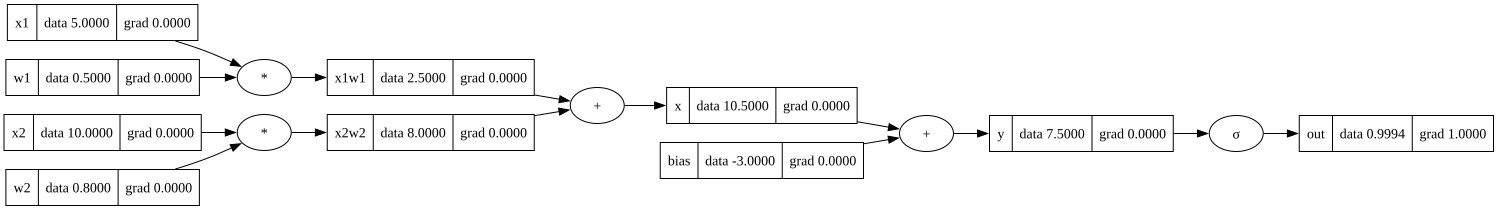

In [7]:
x1=Value(5, 'x1')
x2=Value(10, 'x2')
w1=Value(0.5, 'w1')
w2=Value(0.8, 'w2')

bias=Value(-3, 'bias')

x1w1 = x1*w1
x1w1.label = 'x1w1'
x2w2 = x2*w2
x2w2.label = 'x2w2'

x=x1w1+x2w2
x.label = 'x'
y=x+bias
y.label = 'y'
out=y.sigmoid()
out.label = 'out'
out.grad=1
draw_dot(out)

## Understanding Why

1. For classification problems, say:
In an imginary world where all boys are 5.8ft and above and the girls under, the classification of \"are you a girl or a boy\" *based on height data can be easily seperated with a **linear line**. Humans do this by visualisng data and drawing a line.
A computer on the hand does this by deriving the equation of that said line, which we know as `y=mx+b` and here, `m=weights` and `b=bias`. (The exact understanding of what \"y\" is a bit more nuanced as we go further).

2. But not all data can be seperated linearly, sometimes, they form odd shapes like curves, etc.
Now, we could make quadratic equations, cubic equations and so on to fit it, but we run into a problem very quick. What we're solving for in these equations increases. A quadratic equation has 2 solutions, a cubic 3, and these still dont encapsulate all the complex shapes we may encounter.
So we use **activation functions** which introduce non linearity.
Example; `ReLU`, Rectilinear Unit. It is very simple. it takes:
argmax(0,input) (lets positive numbers through, makes any negative number 0)

> `ReLU: argmax(0,x)`

This helps us create a sharp bend. Enough sharp bends, and u have a curve, and curves at any point, without fancy schmany equation mingling...

## Part 2 — Manual backpropagation, step by step

With a forward pass in hand, we now walk *backward* through the graph above and assign `.grad` on every node by hand, one operation at a time.

### 1. What a derivative means here

A derivative measures how much one quantity changes when another changes by a tiny amount. Here, the quantity we always differentiate is the final output, so every gradient in this notebook has the shape:

$$
\frac{\partial\, \text{out}}{\partial\, \text{scalar}}
$$

i.e. \"if this earlier value changes slightly, how much does the final output change?\"

The base case is the output with respect to itself:

$$
\frac{\partial\, \text{out}}{\partial\, \text{out}} = 1
$$

the same idea as $\dfrac{d}{dx}x = 1$. More formally, for any $f$:

$$
\frac{d}{dx}f(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

and for $f(x) = x$ this reduces to $\dfrac{(x+h)-x}{h} = 1$.

### 2. The direction of computation: right to left

Backpropagation moves backward through the graph. Starting from the output, we ask: *how does each earlier input influence the final result?* So gradients are computed in the reverse order of the forward pass — we start with $\partial\,\text{out}/\partial\,\text{out}=1$ and propagate that backward through each operation.

### 3. A concrete example with sigmoid

The output above was produced by $\text{out} = \sigma(y)$, where

$$
\sigma(y) = \frac{1}{1+e^{-y}}, \qquad \sigma'(y) = \sigma(y)\bigl(1-\sigma(y)\bigr)
$$

For our sigmoid example, $y=7.5$ and $\sigma(y) \approx 0.9994$, so

$$
\sigma'(y) = 0.9994 \times (1 - 0.9994) \approx 0.00055
$$

That small a gradient is exactly why sigmoid activations can make learning slow in deep networks — see the next section.

### 4. Why this matters: the vanishing gradient problem

Some activation functions, especially sigmoid and tanh, can squash values into a very small range. When that happens, the gradient can become extremely small as it travels backward through many layers.

This makes weight updates very small, so learning becomes slow or effectively stalled:

- if the gradient is tiny, the update is tiny
- if the update is tiny, the parameters change very little
- if the parameters change very little, learning progresses very slowly

#### Gradient descent update rule

A weight update is typically of the form:

$$
W_{\text{new}} = W - \eta \cdot \frac{\partial L}{\partial W}
$$

where $L$ is the loss, $\eta$ is the learning rate, and $\partial L/\partial W$ is the gradient. If the gradient is very small, the change to the weight is also very small.

**Example.** If the gradient is $0.0001$ and the learning rate is $0.01$:

$$
\Delta W = -0.01 \times 0.0001 = -0.000001
$$

That is a very weak update.

#### Why sigmoid is especially prone to this

The sigmoid derivative is bounded above by $0.25$:

$$
\sigma'(x) = \sigma(x)\bigl(1 - \sigma(x)\bigr)
$$

Treating $s=\sigma(x) \in [0,1]$, the product $s(1-s)$ is maximized at $s=0.5$:

$$
0.5 \times (1-0.5) = 0.25
$$

So each sigmoid layer can only pass along a gradient that is at most $0.25$ in magnitude, and repeated layers make the signal shrink quickly.

#### Potential mitigations

1. **Use a different activation function.** Instead of squashing everything into $(0,1)$, ReLU can be used for simple \"on/off\" style decisions. But ReLU has its own failure mode: if the weights feeding a unit are consistently negative, that unit's output — and gradient — is zero for every input, so it \"dies\" and stops learning.

2. **Normalize the input.** This helps with two problems that show up with ReLU:
   - If the incoming weights are too small, pre-activation values cluster near zero and a large fraction of units rarely fire, so their gradient is zero most of the time.
   - If the incoming weights are too large, pre-activation values grow without bound, which can make training unstable (exploding activations/gradients).

   Keeping inputs — and ideally intermediate activations, e.g. via batch/layer normalization — in a well-scaled range keeps more units in the \"active\" region of ReLU and improves gradient flow.

### 5. The chain rule in plain language

The chain rule is the key idea behind backpropagation: if one value depends on another, and that other value depends on a third, the total effect is the *product* of the individual effects.

$$
\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}
$$

or, in function notation:

$$
[f(g(x))]' = f'(g(x)) \cdot g'(x)
$$

The idea in three steps:

1. take the derivative of the outer function
2. leave the inside as-is for the moment
3. multiply by the derivative of the inner function

This is exactly what happens as the gradient flows backward through the graph.

### 6. A second example: tanh

The next part changes the numbers slightly so the output stays in a more informative range for the derivative. Same structure as before, but the activation is `tanh` instead of `sigmoid`.

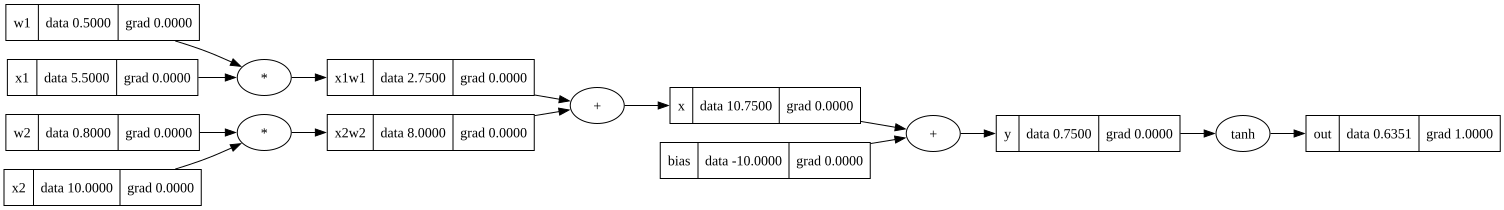

In [8]:
x1=Value(5.5, 'x1')
x2=Value(10, 'x2')
w1=Value(0.5, 'w1')
w2=Value(0.8, 'w2')

bias=Value(-10, 'bias')

x1w1 = x1*w1
x1w1.label = 'x1w1'
x2w2 = x2*w2
x2w2.label = 'x2w2'

x=x1w1+x2w2
x.label = 'x'
y=x+bias
y.label = 'y'
out=y.tanh()
out.label = 'out'
out.grad=1


draw_dot(out)

Using the tanh derivative, we can now propagate the gradient into the previous node.

For tanh:

$$
\frac{d}{dy}\tanh(y) = 1 - \tanh(y)^2
$$

Here $y = 0.75$ and $\text{out} = \tanh(0.75) \approx 0.6351$, so:

$$
1 - (0.6351)^2 \approx 0.5966
$$

So the gradient flowing back to $y$ is about $0.5966$.
We seed this value below.

In [9]:
y.grad=0.5966

### 7. Propagating the gradient to $x$ and bias

Now we move one step backward. The node $y$ is defined as:

$$
y = x + b
$$

Because the derivative of a sum is just the sum of the derivatives:

$$
\frac{\partial y}{\partial x} = 1,
\qquad
\frac{\partial y}{\partial b} = 1
$$

So the gradient coming from $y$ passes through unchanged to both $x$ and $b$:

$$
\frac{\partial \text{out}}{\partial x} = \frac{\partial \text{out}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

and similarly for the bias.

In [10]:
x.grad=0.5966
bias.grad=0.5966

The same idea applies to the sum node:

$$
x = x_1w_1 + x_2w_2
$$

The gradient arriving at $x$ is passed back to both branches of the addition — flowing to both $x_1w_1$ and $x_2w_2$ unchanged.

In [11]:
x1w1.grad=0.5966
x2w2.grad=0.5966

#### Short proof of the same point

For the addition node,

$$
x = x_1w_1 + x_2w_2
$$

the derivative with respect to either branch is simply:

$$
\frac{\partial x}{\partial x_1w_1} = 1,
\qquad
\frac{\partial x}{\partial x_2w_2} = 1
$$

so the gradient is carried through unchanged:

$$
\frac{\partial \text{out}}{\partial x_1w_1}
= \frac{\partial \text{out}}{\partial x} \cdot \frac{\partial x}{\partial x_1w_1}
= \frac{\partial \text{out}}{\partial x}
$$

and the same holds for the other branch.

**AUTOMATIC INVOCATION OF GRADIENT UPDATES**

In [12]:
import math

class Value():

    def __init__(self, data: float, label: str = '', _children=(), _op=''):
        self.data = data
        self.label = label
        self._prev = set(_children)
        self._op = _op
        self.grad = 0.0 # Initialize gradient

    def __add__(self, other):
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other_value.data, _children=(self, other_value), _op='+')
        # Updating Gradients: Remember/Observe yourself: Addition Gradients flow backward (partial derivative of variable treated as constant)
        def _backward():
            other_value.grad += out.grad
            self.grad += out.grad
        out._backward = _backward
        return out

    def __sub__(self, other):
        # Ensure 'other' is a Value object
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(self.data - other_value.data, _children=(self, other_value), _op='-')
        # Updating Gradients: same as addition
        def _backward():
            other_value.grad += out.grad
            self.grad += -out.grad  # Note: negative for subtraction
        out._backward = _backward
        return out

    def __rsub__(self, other):
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(other_value.data - self.data, _children=(other_value, self), _op='-')
        # Updating Gradients: Reason: derivative of y-x wrt x = -1
        def _backward():
            other_value.grad += -out.grad
            self.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(round(self.data * other_value.data, DES_PRECISION), _children=(self, other_value), _op='*')
        # Updating Gradients: for multiplication, gradient flows as x*grad_y + y*grad_x
        def _backward():
            other_value.grad += out.grad * self.data
            self.grad += out.grad * other_value.data
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self.__mul__(other)

    def __truediv__(self, other):
        other_value = other if isinstance(other, Value) else Value(other)
        out = Value(round(self.data / other_value.data, DES_PRECISION), _children=(self, other_value), _op='/')
        # Updating Gradients: for division, gradient flows as grad_y/y - x*grad_y/y^2
        def _backward():
            other_value.grad += out.grad / self.data
            self.grad += -out.grad * (other_value.data / (self.data ** 2))
        out._backward = _backward
        return out

    def __pow__(self, other):
        if isinstance(other, (int, float)):
            out = Value(round(self.data ** other, DES_PRECISION), _children=(self,), _op='^')
            # Updating Gradients: for power, gradient is power * x^(power-1) * grad
            def _backward():
                self.grad += out.grad * other * (self.data ** (other - 1))
            out._backward = _backward
        else:
            out = Value(round(self.data ** other.data, DES_PRECISION), _children=(self, other), _op='^')
            # Updating Gradients: for general power, more complex
            def _backward():
                # d/dx (x^y) = y*x^(y-1) + ln(x)*x^y*dy/dx
                self.grad += out.grad * (other.data * (self.data ** (other.data - 1)) + 
                              math.log(self.data) * (self.data ** other.data) * other.grad)
                other_value.grad += out.grad * (math.log(self.data) * (self.data ** other.data))
            out._backward = _backward
        return out

    def relu(self):
        out_data = 0 if self.data < 0 else self.data
        out = Value(out_data, _children=(self,), _op='ReLU')
        # Updating Gradients: ReLU gradient is 1 if input > 0, else 0
        def _backward():
            self.grad += out.grad * (1 if self.data >= 0 else 0)
        out._backward = _backward
        return out

    def tanh(self):
        out_data = math.tanh(self.data)
        out = Value(out_data, _children=(self,), _op='tanh')
        # Updating Gradients: derivative of tanh is 1 - tanh^2
        def _backward():
            self.grad += out.grad * (1 - out_data ** 2)
        out._backward = _backward
        return out

    def sigmoid(self):
        out_data = 1 / (1 + math.exp(-self.data)) # Corrected sigmoid formula
        out = Value(round(out_data, DES_PRECISION), _children=(self,), _op='σ')
        # Updating Gradients: derivative of sigmoid is σ*(1-σ)
        def _backward():
            self.grad += out.grad * out_data * (1 - out_data)
        out._backward = _backward
        return out

    def __repr__(self):
        return f"Value(data={self.data:.4f}, label='{self.label}', grad={self.grad:.4f})"

    def backward(self):
        # Topological sort of the computation graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
            topo.append(v)

        build_topo(self)
        # Go in reverse topological order
        self.grad = 1.0  # Seed the gradient of the output
        for node in reversed(topo):
            if hasattr(node, '_backward'):
                node._backward()


# Building "Neurons"

A **neuron** in this context is essentially just a **node**, like the circles we commonly see in diagrams of Multi-Layer Perceptrons (MLPs). While MLPs are one of the simplest forms of neural networks, they form the foundation for most modern AI architectures.

---

### The Titanic Example
To see how this works, consider a simplified example using the Titanic dataset. Our goal is to predict whether a passenger survived based on three parameters:

* **Age**
* **Gender** (Coded as an integer: `1` for female, `0` for male)
* **Fare Type** (e.g., 1st, 2nd, or 3rd class. *Note: While one-hot encoding is usually preferred, we will stick to 1, 2, 3 for simplicity.*)

This gives us three numeric inputs: $x_1, x_2, x_3$.

---

### Inside the Neuron: The Math

A single neuron takes these inputs, multiplies them by their corresponding weights, and adds a bias. This yields the linear equation:

$$
\text{output} = w_1x_1 + w_2x_2 + w_3x_3 + \text{bias}
$$

A **hidden layer** consists of many such neurons. Because each neuron is connected to all inputs but possesses its own unique weights and biases, they each produce different outputs.

Think of it like different equations to detect different things, connections etc.

---

### Introducing Activation Functions
*(exactly as seen earlier)*

Without an activation function, this architecture is just a multidimensional version of a simple linear equation ($y = mx + b$). Because real-world data very rarely falls along a straight line or features linear decision boundaries, we need a mechanism to introduce curvature and non-linearity.

This is the role of **activation functions**, which wrap around the output of each individual neuron. Typical activation functions include:

* **ReLU**: Returns $\max(0, x)$, zeroing out all negative values.
* **Sigmoid**: Bounds output between (0,1): useful for binary classification problems:  Yes / No percentages 
* **Softmaxx**: Useful for squashing outputs into probabilities distibutions.
* **Tanh**: Bounds outputs smoothly between $[-1, 1] $. (even sigmoid does, as seen earlier in the \"vanishing gradient problem\")

---

### The Final Formula

By applying an activation function—essentially calculating $f(wx + b)$—the network can capture complex, non-linear patterns.

> This allows neural networks to solve highly intricate problems **without** requiring us to manually engineer complex quadratic or cubic equations as data complexity scales.

In [13]:
"""
direclty taken from micrograd's nn.py
"""

import random
# from micrograd.engine import Value

class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"


### How does it find the correct equations though?

We use ERRORS.

To minimize errors, we have to go against the direction of the gradient, so we do `Wo - grad * c`.

**(Think:**
If we're on a slope, facing upwards, th### How does it find the correct equations though?

We use ERRORS.

To minimize errors, we have to go against the direction of the gradient, so we do `Wo - grad * c`.

**(Think:**
If we're on a slope, facing upwards, the derivative at that point, in the way we're facing, is UP. We need to continue going up to find the local maxima.

If we're on a slope, facing downwards, the derivative at that point, in the way we're facing (the slope is going), is DOWN. We need to go BACKWARDS to find the minima (which is negative, which is the direction of the slope at that point).**)**

In basic algebra class, the error we use is "least squares" or MSE: Mean Squared Error off of target. This is the principle of algebraic linear regression [Search AI Mode Conversation].

You may notice a slight issue here though; this is used to FIT data, not separate, so for prediction of linearly spaced variables, it works fine. It breaks for classification problems or separating data.

So for these problems, we need to use errors, not from the absolute value, but from the PROBABILITY of classes.

*   Assume output $A = 5$, it should have been $6$.
*   $\text{Error} = -1$
*   Need to push output UP
*   Nudge weights in direction of gradient

Simple.

*   Assume **Input** = grid of pixels of a cat image.
*   Assume **Output** $A = 7$ for cat, $B = 8$ for dog, and $C = 4$ for fish.

These numbers mean nothing in their current form, but we can assume a higher number = higher likelihood of class. So for us, it's DOG.

But what's the probability?

We use a **Softmax** function. It converts a vector (for most use cases, think of it just like a list of numbers) to probability distributions. [Each number is converted to something between 0 and 1, and they all add up to 1.] Essentially, probability.

Applying Softmax, we get:
*   $A = 0.265$
*   $B = 0.721$
*   $C = 0.013$

(There's a lot of reasons we use Softmax and not simpler arithmetic, which you can find [here](https://geeksforgeeks.org).)

Now to push the probability of CAT UP, we first need some metric to see just HOW wrong it is.

In Machine Learning, this is often found by **"Cross-Entropy"**. It measures how wrong a classification model's predicted probabilities are compared to the true labels.

But this is not the problem we had at hand. We need to SEPARATE data [classic binary classification problem]...e derivative at that point, in the way we're facing, is UP. We need to continue going up to find the local maxima.

If we're on a slope, facing downwards, the derivative at that point, in the way we're facing (the slope is going), is DOWN. We need to go BACKWARDS to find the minima (which is negative, which is the direction of the slope at that point).**)**

In basic algebra class, the error we use is "least squares" or MSE: Mean Squared Error off of target. This is the principle of algebraic linear regression [Search AI Mode Conversation].

You may notice a slight issue here though; this is used to FIT data, not separate, so for prediction of linearly spaced variables, it works fine. It breaks for classification problems or separating data.

So for these problems, we need to use errors, not from the absolute value, but from the PROBABILITY of classes.

*   Assume output $A = 5$, it should have been $6$.
*   $\text{Error} = -1$
*   Need to push output UP
*   Nudge weights in direction of gradient

Simple.

*   Assume **Input** = grid of pixels of a cat image.
*   Assume **Output** $A = 7$ for cat, $B = 8$ for dog, and $C = 4$ for fish.

These numbers mean nothing in their current form, but we can assume a higher number = higher likelihood of class. So for us, it's DOG.

But what's the probability?

We use a **Softmax** function. It converts a vector (for most use cases, think of it just like a list of numbers) to probability distributions. [Each number is converted to something between 0 and 1, and they all add up to 1.] Essentially, probability.

Applying Softmax, we get:
*   $A = 0.265$
*   $B = 0.721$
*   $C = 0.013$

(There's a lot of reasons we use Softmax and not simpler arithmetic, which you can find [here](https://geeksforgeeks.org).)

Now to push the probability of CAT UP, we first need some metric to see just HOW wrong it is.

In Machine Learning, this is often found by **"Cross-Entropy"**. It measures how wrong a classification model's predicted probabilities are compared to the true labels.

But this is not the problem we had at hand. We need to SEPARATE data [classic binary classification problem]...


In [ ]:

#lets take a new example to see how the backward pass works
w = Value(0.0, label='w')

#The goal is to minimise the loss here for this equation (adjust w to get to the minimum possible value )
loss = (w - 3) ** 2
loss.label = 'loss'
#if u know basic math, you know that anything squared is always positive, 
# so the minimum value of this loss function is 0
#  which occurs when w=3. 

loss.backward()

print(f"w     = {w.data}")
print(f"loss  = {loss.data}")
print(f"dw    = {w.grad}")

w     = 0.0
loss  = 9.0
dw    = 6.0


Our Loss? (Remember: target=minimum, not 0 (The computer doesn't)

### The Update

We now have everything we need.

The gradient tells us the direction to move.

But how far should we move?

We introduce a **learning rate**, usually written as $\eta$.

The basic gradient descent update is:

$$
w_{\text{new}}
=
w_{\text{old}}
-
\eta
\frac{\partial L}{\partial w}
$$

The minus sign is important.

The gradient points toward increasing loss, so we move **against** it.

For example, if:

$$
w=0,\qquad
\frac{\partial L}{\partial w}=-6,\qquad
\eta=0.1
$$

then:

$$
w_{\text{new}}
=
0-(0.1)(-6)
=
0.6
$$

We have moved from:

$$
0 \rightarrow 0.6
$$

which takes us closer to the minimum at $w=3$.

In [16]:
w = Value(0.0, label='w')

loss = (w - 3) ** 2
loss.backward()

learning_rate = 0.1

print("Before update:")
print(f"w = {w.data:.4f}")
print(f"loss = {loss.data:.4f}")
print(f"gradient = {w.grad:.4f}")

# Gradient descent update
w.data -= learning_rate * w.grad

print("\nAfter update:")
print(f"w = {w.data:.4f}")

Before update:
w = 0.0000
loss = 9.0000
gradient = 6.0000

After update:
w = -0.6000


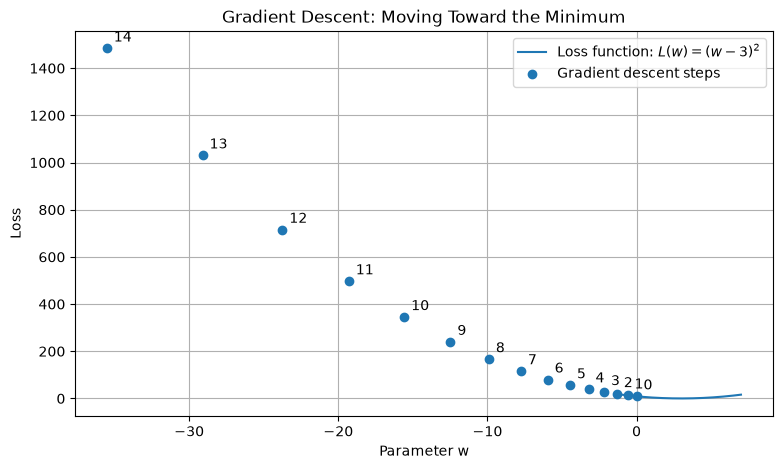

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Loss function
x = np.linspace(-1, 7, 400)
y = (x - 3) ** 2

# Run gradient descent
w = Value(0.0, label='w')
learning_rate = 0.1

positions = []
losses = []

for step in range(15):
    loss = (w - 3) ** 2
    loss.backward()

    positions.append(w.data)
    losses.append(loss.data)

    # Update
    w.data -= learning_rate * w.grad

    # Reset gradient before next iteration
    w.grad = 0.0

# Plot the loss landscape
plt.figure(figsize=(9, 5))

plt.plot(x, y, label="Loss function: $L(w)=(w-3)^2$")
plt.scatter(positions, losses, zorder=3, label="Gradient descent steps")

for i, (px, py) in enumerate(zip(positions, losses)):
    plt.annotate(
        str(i),
        (px, py),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Parameter w")
plt.ylabel("Loss")
plt.title("Gradient Descent: Moving Toward the Minimum")
plt.legend()
plt.grid(True)

plt.show()

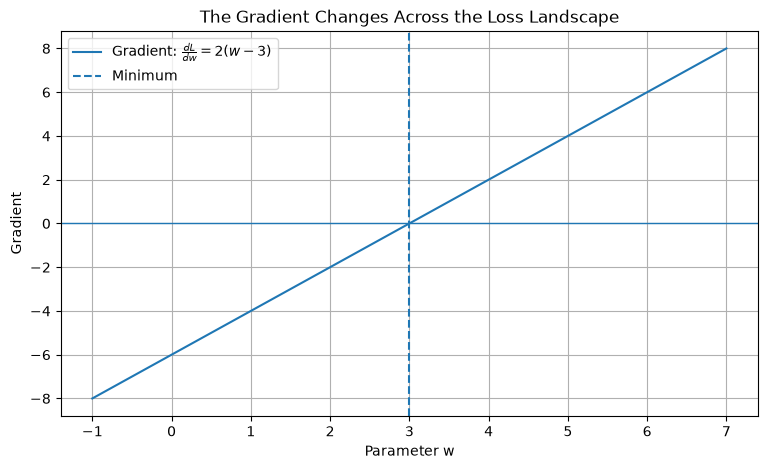

In [20]:
gradient = 2 * (x - 3)

plt.figure(figsize=(9, 5))

plt.plot(x, gradient, label=r"Gradient: $\frac{dL}{dw}=2(w-3)$")
plt.axhline(0, linewidth=1)
plt.axvline(3, linestyle="--", label="Minimum")

plt.xlabel("Parameter w")
plt.ylabel("Gradient")
plt.title("The Gradient Changes Across the Loss Landscape")
plt.legend()
plt.grid(True)

plt.show()

## The Learning Rate

There is one problem with our update:

$$
w_{\text{new}}
=
w-\eta\frac{\partial L}{\partial w}
$$

How large should $\eta$ be?

This is the **learning rate**.

It controls how large each step is.

A learning rate that is:

- too small → learning can be extremely slow
- reasonable → we move efficiently toward the minimum
- too large → we can overshoot the minimum or even diverge

Let's see this rather than just talking about it.

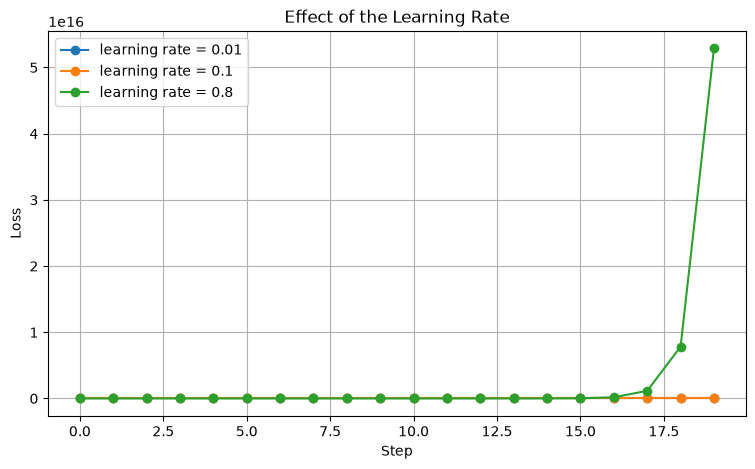

In [21]:
learning_rates = [0.01, 0.1, 0.8]

plt.figure(figsize=(9, 5))

for lr in learning_rates:
    w = Value(0.0)
    trajectory = []

    for step in range(20):
        loss = (w - 3) ** 2
        loss.backward()

        trajectory.append(loss.data)

        w.data -= lr * w.grad
        w.grad = 0.0

    plt.plot(
        range(len(trajectory)),
        trajectory,
        marker='o',
        label=f"learning rate = {lr}"
    )

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Effect of the Learning Rate")
plt.legend()
plt.grid(True)

plt.show()